# 3D Grounding-DETR Visualization Demo

This notebook demonstrates how to visualize predictions from the 3D Grounding-DETR model on CT volumes.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import random_split

from models import build_model
from datasets import RSNAVolumeDataset
from utils.visualization import (
    visualize_single_slice,
    visualize_multi_slice,
    save_visualization
)
from utils.metrics import compute_map

%matplotlib inline

## 1. Load Model and Dataset

In [2]:
# Configuration
CHECKPOINT_PATH = 'checkpoints/model_best.pth'
DATA_DIR = '/home/woody/iwi5/iwi5378h/rsna2023'
SAMPLE_IDX = 0  # Index within test dataset
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
# Load checkpoint
print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
config = checkpoint['config']

# Build model
print("Building model...")
model = build_model(config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

Loading checkpoint from checkpoints/model_best.pth...
Building model...
Model built with 53,832,894 parameters
Model loaded successfully!


In [4]:
# Load full dataset and split into train/val/test using the same logic as train.py
print(f"Loading dataset from {DATA_DIR}...")

# Create full dataset (without augmentation for evaluation)
full_dataset = RSNAVolumeDataset(
    data_dir=DATA_DIR,
    target_width=config['data']['target_width'],
    train=False,
    augment=False,
    image_format=config['data'].get('image_format', 'dcm')
)

# Use the same split ratios and seed as training
train_ratio = config['data'].get('train_split', 0.7)
val_ratio = config['data'].get('val_split', 0.15)
test_ratio = config['data'].get('test_split', 0.15)
random_seed = config['data'].get('random_seed', 42)

# Normalize ratios
total_ratio = train_ratio + val_ratio + test_ratio
train_ratio /= total_ratio
val_ratio /= total_ratio
test_ratio /= total_ratio

# Calculate split sizes
total_size = len(full_dataset)
train_size = int(total_size * train_ratio)
val_size = int(total_size * val_ratio)
test_size = total_size - train_size - val_size

# Split with the SAME seed as training for reproducibility
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(random_seed)
)

print(f"Full dataset size: {len(full_dataset)}")
print(f"Split: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

# Print file IDs for each split (remove after verification)
def _get_ids(subset): return [full_dataset.seg_files[i].replace('.nii','') for i in subset.indices]
print(f"Train IDs: {_get_ids(train_dataset)}")
print(f"Val IDs: {_get_ids(val_dataset)}")
print(f"Test IDs: {_get_ids(test_dataset)}")

Loading dataset from /home/woody/iwi5/iwi5378h/rsna2023...
Found 193 NumPy volumes
Image format: numpy
Full dataset size: 193
Split: train=135, val=28, test=30
Train IDs: ['16066', '47155', '17605', '10252', '4622', '31021', '6305', '7818', '40471', '1201', '22232', '6130', '21057', '26343', '12674', '18207', '22397', '40186', '60755', '63418', '60302', '13041', '64520', '54917', '63146', '13925', '6575', '31571', '12900', '19657', '58027', '19360', '47305', '19468', '54830', '42973', '43416', '40496', '39222', '52970', '5118', '15415', '33526', '64117', '527', '30902', '51033', '62556', '12039', '26980', '26840', '39628', '32670', '47438', '55965', '31085', '8236', '36257', '25359', '40430', '24774', '31200', '20664', '5103', '43233', '13774', '28079', '5260', '525', '62573', '22479', '28432', '48324', '13666', '15539', '55449', '49753', '35190', '34224', '30843', '60307', '8413', '12840', '10180', '23644', '137', '29167', '32991', '36753', '32243', '4890', '47610', '397', '55694', '3

## 2. Run Inference

In [5]:
# Get sample from TEST dataset
sample = test_dataset[SAMPLE_IDX]
volume = sample['volume']  # (1, D, H, W)
series_id = sample['study_id']
gt_boxes = sample['boxes'].numpy()
gt_labels = sample['labels'].numpy()

print(f"[TEST Sample {SAMPLE_IDX}]")
print(f"Series ID: {series_id}")
print(f"Volume shape: {volume.shape}")
print(f"Ground truth objects: {len(gt_boxes)}")

[TEST Sample 0]
Series ID: 45406
Volume shape: torch.Size([1, 28, 128, 128])
Ground truth objects: 5


In [6]:
# Run inference
print("Running inference...")
with torch.no_grad():
    volume_input = volume.unsqueeze(0).to(DEVICE).float()  # (1, 1, D, H, W)
    outputs = model(volume_input)
    
    pred_logits = outputs['pred_logits'][0]  # (num_queries, num_classes+1)
    pred_boxes = outputs['pred_boxes'][0]    # (num_queries, 6)
    
    # Apply softmax and exclude background class (last class)
    pred_probs = pred_logits.softmax(-1)[:, :-1]  # (num_queries, num_classes)
    
    # For each query, get predicted class and score from foreground classes only
    pred_labels = pred_probs.argmax(-1)
    pred_scores = pred_probs.max(-1)[0]
    
    # Move to CPU
    pred_boxes = pred_boxes.cpu().numpy()
    pred_labels = pred_labels.cpu().numpy()
    pred_scores = pred_scores.cpu().numpy()

print("Inference complete!")

Running inference...
Inference complete!


In [7]:
# Post-processing: Get the top prediction for each class
# Select the highest-scoring prediction per class

num_classes = config['model']['num_classes']

# For each class, find the query with the highest score
pred_boxes_per_class = []
pred_labels_per_class = []
pred_scores_per_class = []

for class_id in range(num_classes):
    scores_for_class = pred_probs[:, class_id]
    best_query_idx = scores_for_class.argmax().item()
    best_score = scores_for_class[best_query_idx].item()
    
    pred_boxes_per_class.append(pred_boxes[best_query_idx])
    pred_labels_per_class.append(class_id)
    pred_scores_per_class.append(best_score)

# Convert to arrays
pred_boxes_filtered = np.array(pred_boxes_per_class)
pred_labels_filtered = np.array(pred_labels_per_class)
pred_scores_filtered = np.array(pred_scores_per_class)

print(f"Predictions (top-1 per class): {len(pred_boxes_filtered)}")
for i, (box, label, score) in enumerate(zip(pred_boxes_filtered, pred_labels_filtered, pred_scores_filtered)):
    print(f"  {i+1}. Class {label}, Score: {score:.3f}")

Predictions (top-1 per class): 5
  1. Class 0, Score: 0.997
  2. Class 1, Score: 1.000
  3. Class 2, Score: 0.997
  4. Class 3, Score: 0.999
  5. Class 4, Score: 0.999


## 3. Single-Slice Visualization

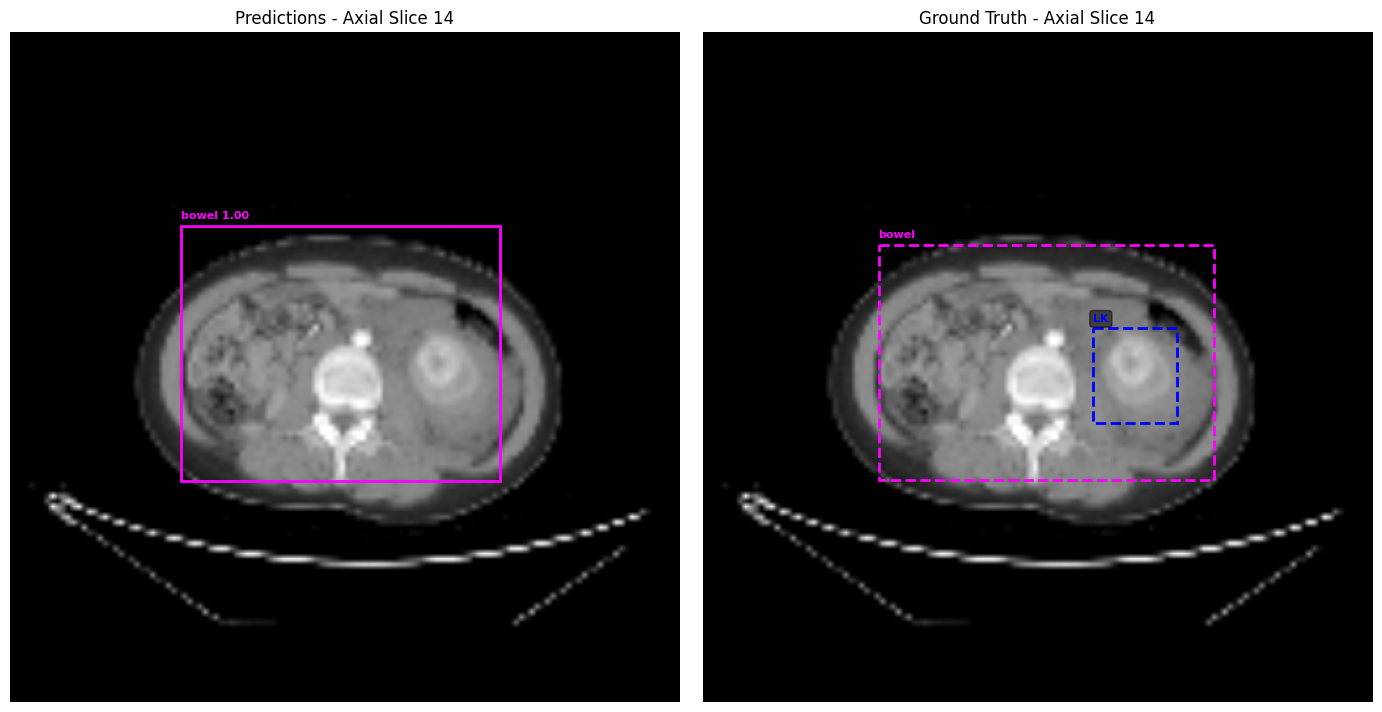

In [8]:
# Visualize middle slice
volume_np = volume[0].numpy()  # Remove channel dimension
middle_slice = volume_np.shape[0] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=middle_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='axial',
    figsize=(14, 7)
)

plt.show()

## 4. Multi-Slice Visualization (Axial & Sagittal & Coronal)

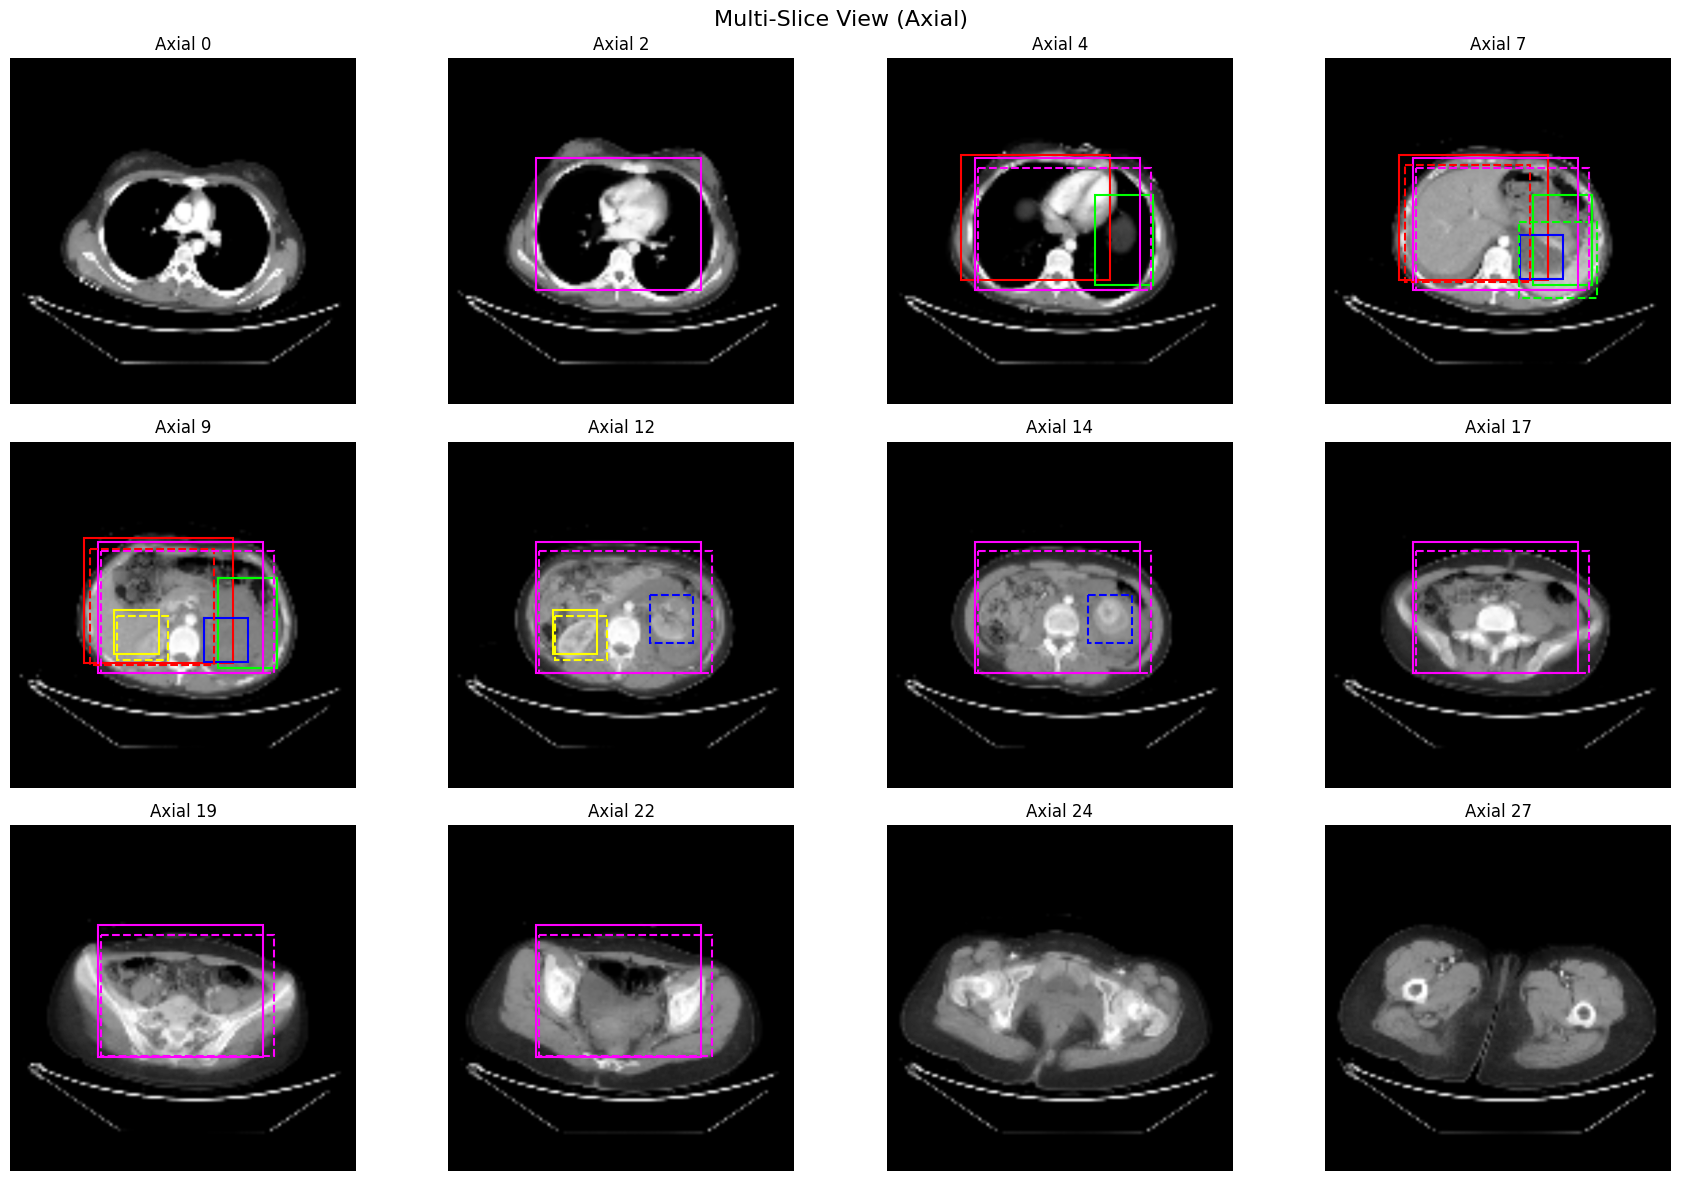

In [9]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='axial',
    figsize=(18, 12)
)

plt.show()

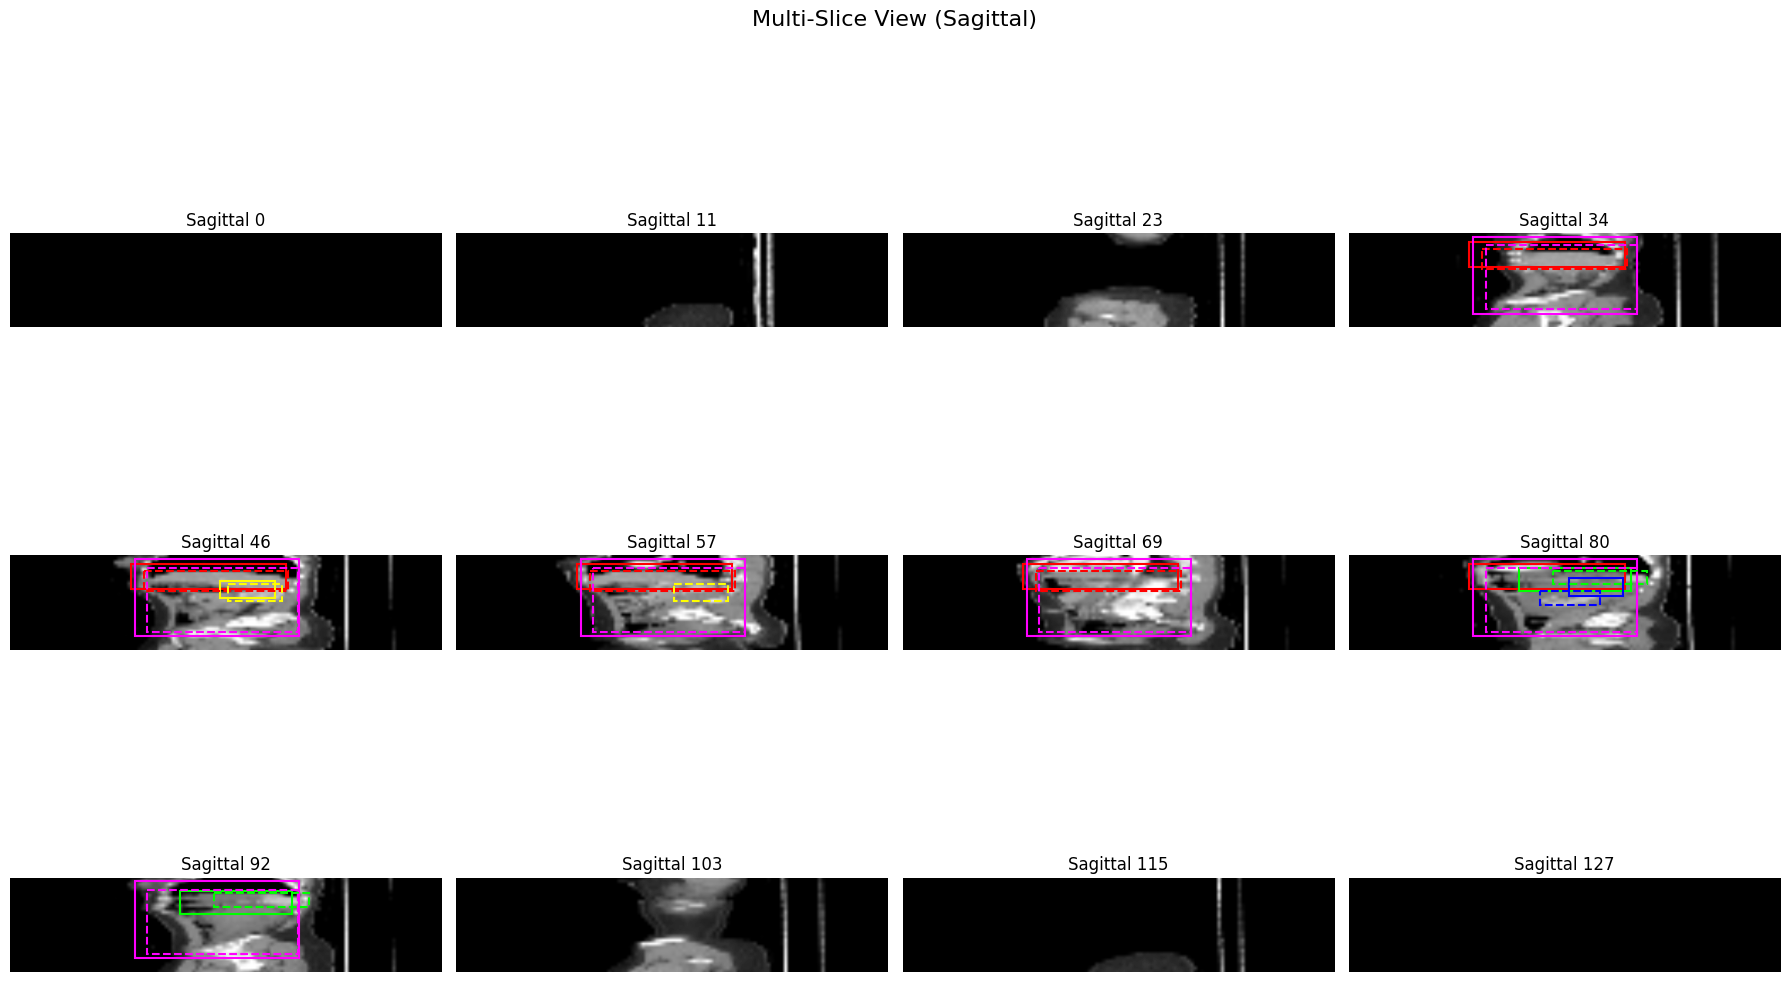

In [10]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='sagittal',
    figsize=(18, 12)
)

plt.show()

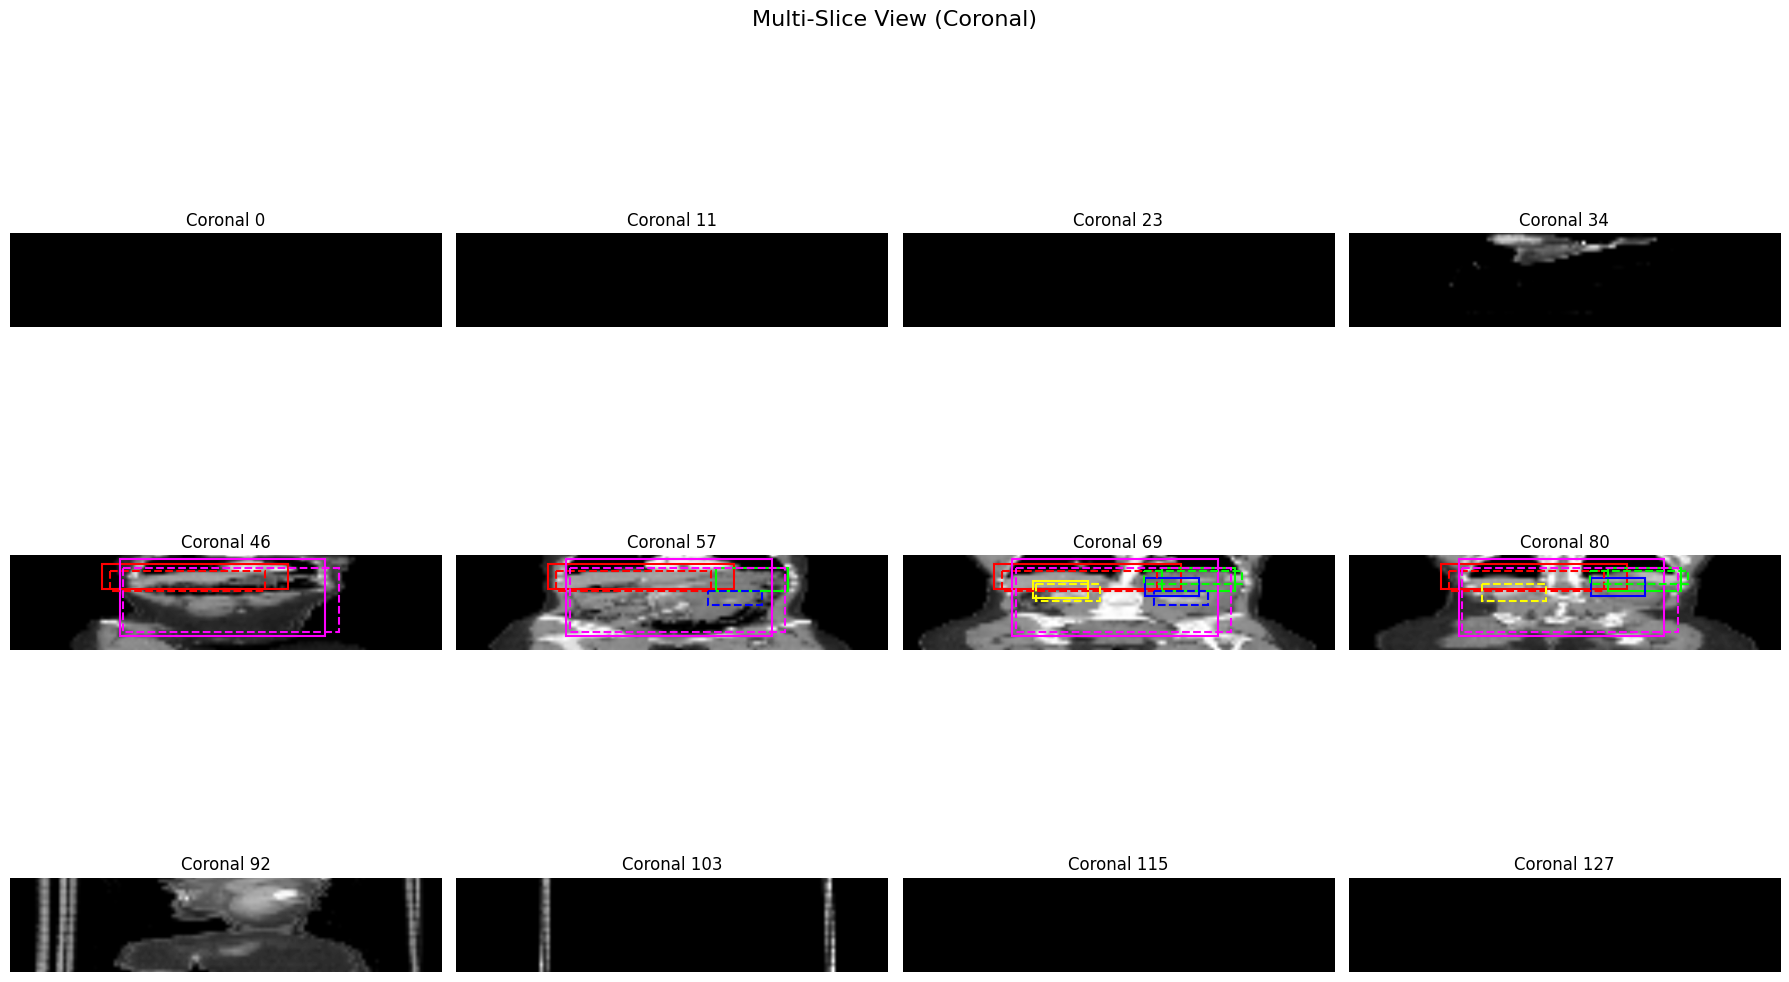

In [11]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='coronal',
    figsize=(18, 12)
)

plt.show()

## 5. Evaluate mAP on Entire Test Dataset

In [12]:
# Evaluate mAP on the ENTIRE TEST dataset
from tqdm import tqdm

NUM_TEST_SAMPLES = len(test_dataset)
num_classes = config['model']['num_classes']
iou_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

all_predictions = []
all_ground_truths = []

print(f"Evaluating on entire TEST dataset ({NUM_TEST_SAMPLES} samples)...")
print("=" * 50)

for idx in tqdm(range(NUM_TEST_SAMPLES), desc="Running inference"):
    sample = test_dataset[idx]
    
    with torch.no_grad():
        volume_input = sample['volume'].unsqueeze(0).to(DEVICE).float()
        outputs = model(volume_input)
        
        pred_logits = outputs['pred_logits'][0]
        pred_boxes = outputs['pred_boxes'][0]
        
        # Softmax, exclude background (last class)
        pred_probs = pred_logits.softmax(-1)[:, :-1]
        pred_scores = pred_probs.max(-1)[0]
        pred_labels = pred_probs.argmax(-1)
        
        all_predictions.append({
            'boxes': pred_boxes.cpu().numpy(),
            'scores': pred_scores.cpu().numpy(),
            'labels': pred_labels.cpu().numpy()
        })
        
    all_ground_truths.append({
        'boxes': sample['boxes'].numpy(),
        'labels': sample['labels'].numpy()
    })

# Compute mAP
test_map_results = compute_map(
    predictions=all_predictions,
    ground_truths=all_ground_truths,
    num_classes=num_classes,
    iou_thresholds=iou_thresholds
)

print("\n" + "=" * 60)
print(f"📊 FINAL TEST SET RESULTS ({NUM_TEST_SAMPLES} samples)")
print("=" * 60)
print("⚠️  These samples were NEVER seen during training or validation!")
print("-" * 60)
for metric_name, value in test_map_results.items():
    print(f"{metric_name}: {value:.4f}")
print("=" * 60)

Evaluating on entire TEST dataset (30 samples)...


Running inference: 100%|██████████| 30/30 [05:50<00:00, 11.69s/it]



📊 FINAL TEST SET RESULTS (30 samples)
⚠️  These samples were NEVER seen during training or validation!
------------------------------------------------------------
mAP@0.1: 0.9649
mAP@0.2: 0.9052
mAP@0.3: 0.7764
mAP@0.4: 0.5678
mAP@0.5: 0.4309
mAP@0.6: 0.2803
mAP@0.7: 0.1552
mAP: 0.5830


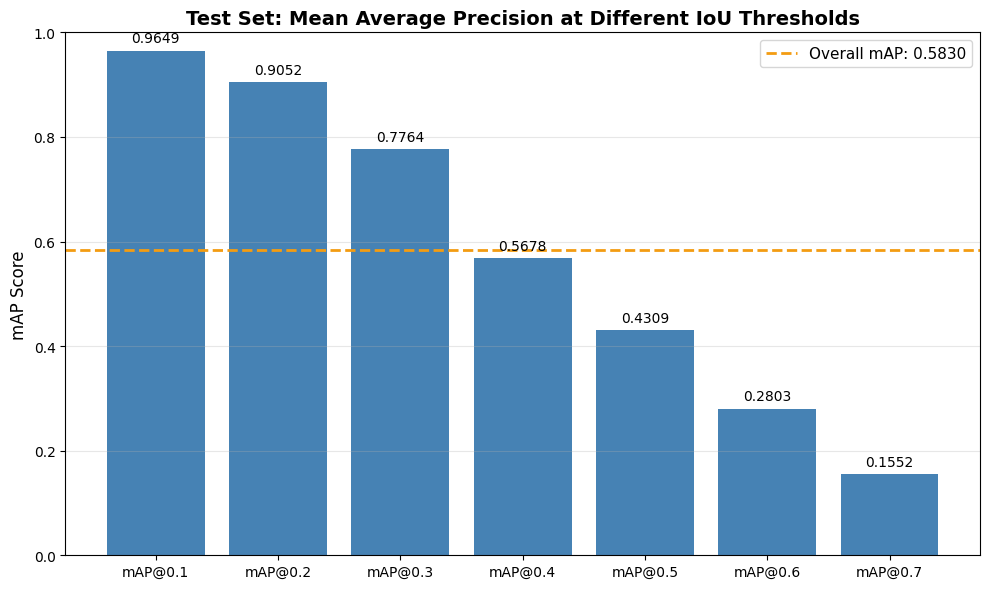

In [13]:
# Visualize mAP results
metrics = [k for k in test_map_results.keys() if k != 'mAP']
values = [test_map_results[k] for k in metrics]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color='steelblue')
ax.axhline(y=test_map_results['mAP'], color='#f39c12', linestyle='--', 
           linewidth=2, label=f"Overall mAP: {test_map_results['mAP']:.4f}")

ax.set_ylabel('mAP Score', fontsize=12)
ax.set_title('Test Set: Mean Average Precision at Different IoU Thresholds', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()